# Calculate mAP scores for bulk profiles of only failing cells comparing the compounds at an MOA level to the control (DMSO)

In [1]:
import os
import pathlib

import numpy as np
import pandas as pd
from copairs import map  # noqa: A004
from copairs.matching import assign_reference_index
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_density,
    ggplot,
    labs,
    scale_color_manual,
    scale_fill_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from scipy.stats import mannwhitneyu
from tqdm import tqdm

## Helper functions

In [2]:
# Perform mean average precision calculation
def get_mean_average_precision(  # noqa: PLR0913
    activity_df: pd.DataFrame,
    pos_sameby: list,
    pos_diffby: list,
    neg_sameby: list,
    neg_diffby: list,
    seed: int = 0,
) -> pd.DataFrame:
    """Calculate mean average precision for activity data.

    Args:
        activity_df (pd.DataFrame): Activity data.
        pos_sameby (list): Positive samples to compare.
        pos_diffby (list): Positive samples to compare.
        neg_sameby (list): Negative samples to compare.
        neg_diffby (list): Negative samples to compare.
        seed (int, optional): Random seed for reproducibility. Defaults to 0.

    Returns:
        pd.DataFrame: Mean average precision results.
    """
    metadata = activity_df.filter(regex="^Metadata")
    profiles = activity_df.filter(regex="^(?!Metadata)").values

    activity_ap = map.average_precision(
        metadata, profiles, pos_sameby, pos_diffby, neg_sameby, neg_diffby
    )

    activity_map = map.mean_average_precision(
        activity_ap, pos_sameby, seed=seed, null_size=10000, threshold=0.05
    )
    activity_map["-log10(p-value)"] = -activity_map["corrected_p_value"].apply(np.log10)
    return activity_map


# Calculate proportion of points above, below, and equal to y=x per dose
def proportion_above_below_y_eq_x(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate the proportion of points above, below, and equal to the y=x line.

    Args:
        df (pd.DataFrame): DataFrame containing the activity data.

    Returns:
        pd.DataFrame: Dataframe with proportions and counts per dose.
    """
    results = []
    for dose, group in df.groupby("Metadata_dose_recode"):
        above = (
            group["mean_average_precision_postQC"]
            > group["mean_average_precision_preQC"]
        ).sum()
        below = (
            group["mean_average_precision_postQC"]
            < group["mean_average_precision_preQC"]
        ).sum()
        equal = (
            group["mean_average_precision_postQC"]
            == group["mean_average_precision_preQC"]
        ).sum()
        total = len(group)
        results.append(
            {
                "Metadata_dose_recode": dose,
                "proportion_above": above / total if total > 0 else np.nan,
                "proportion_below": below / total if total > 0 else np.nan,
                "proportion_equal": equal / total if total > 0 else np.nan,
                "n_points": total,
            }
        )
    return pd.DataFrame(results)


def calculate_replicate_cosine_similarity(
    activity_df: pd.DataFrame,
    group_cols: list[str] | None = None,
    exclude_profile_cols: list[str] | None = None,
    min_replicates: int = 2,
) -> pd.DataFrame:
    """Calculate pairwise replicate cosine similarity for all treatment groups.

    The returned rows are one compound-dose (or general group) each. The mean summarizes all
    pairwise cosine similarities among replicate profiles in that group.

    This function measures within-group reproducibility of feature profiles
    (e.g., compounds, doses, and DMSO controls) by computing cosine similarity
    between replicate feature vectors in a shared feature space.

    Args:
        activity_df (pd.DataFrame): DataFrame containing activity data with metadata and
            profile columns (feature space used for cosine similarity).
        group_cols (list[str], optional): List of metadata columns to group by. Defaults
            to ["Metadata_broad_sample", "Metadata_dose_recode"].
        exclude_profile_cols (list[str], optional): List of numeric columns to exclude
            from profile data (e.g., "failed_proportion").
            Defaults to ["failed_proportion"].
        min_replicates (int, optional): Minimum number of replicates required to
            calculate cosine similarity. Defaults to 2.

    Returns:
        pd.DataFrame: DataFrame with group columns and summary statistics of
            pairwise cosine similarity for each treatment group.
    """
    # Set default columns if not provided
    if group_cols is None:
        group_cols = ["Metadata_broad_sample", "Metadata_dose_recode"]
    if exclude_profile_cols is None:
        exclude_profile_cols = ["failed_proportion"]

    # Use full dataset (no external filtering / map restriction)
    activity_subset = activity_df.copy()

    # Identify profile columns by excluding metadata and specified columns
    metadata_cols = activity_subset.filter(regex="^Metadata").columns
    numeric_cols = activity_subset.select_dtypes(include="number").columns
    profile_cols = [
        col
        for col in numeric_cols
        if col not in metadata_cols and col not in exclude_profile_cols
    ]

    # Calculate pairwise cosine similarity for each group and store results
    results = []
    for group_values, group_df in activity_subset.groupby(group_cols, dropna=False):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        # Extract profile data and handle NaN values by replacing them with zeros
        profiles = group_df[profile_cols].to_numpy(dtype=float)
        profiles = np.nan_to_num(profiles, nan=0.0, posinf=0.0, neginf=0.0)

        # Skip groups with fewer than the minimum number of replicates
        if profiles.shape[0] < min_replicates:
            continue

        # Ensure proper cosine similarity even if upstream normalization drifted
        norms = np.linalg.norm(profiles, axis=1, keepdims=True)
        profiles = np.divide(
            profiles, norms, out=np.zeros_like(profiles), where=norms != 0
        )

        cosine_matrix = profiles @ profiles.T

        # Extract upper triangle (excluding diagonal)
        pair_indices = np.triu_indices(profiles.shape[0], k=1)
        pairwise_cosine = cosine_matrix[pair_indices]

        # Store results with group values and summary statistics
        results.append(
            {
                **dict(zip(group_cols, group_values, strict=True)),
                "n_replicates": profiles.shape[0],
                "n_pairwise_comparisons": pairwise_cosine.size,
                "mean_pairwise_cosine_similarity": pairwise_cosine.mean(),
                "median_pairwise_cosine_similarity": np.median(pairwise_cosine),
                "std_pairwise_cosine_similarity": (
                    pairwise_cosine.std(ddof=1) if pairwise_cosine.size > 1 else 0.0
                ),
            }
        )

    return pd.DataFrame(results)

## Load in the data for post QC and only failing QC cells

In [3]:
MIN_REPLICATES = 2

input_dir = pathlib.Path(
    "/home/jenna/mnt/bandicoot/LINCS_data/processed_profiles/single_cell_profiles"
)

output_dir = pathlib.Path("./mAP_results")
output_dir.mkdir(parents=True, exist_ok=True)

post_qc_file = pathlib.Path(
    input_dir,
    "whole_batch_post_qc_cpd_replicates.parquet",
)
post_qc_df = pd.read_parquet(post_qc_file)
post_qc_df = post_qc_df.drop(
    columns=["broad_id", "pert_iname", "moa", "replicate_name"]
)
post_qc_df["Metadata_sc_count_failed_qc"] = (
    post_qc_df["Metadata_sc_count_failed_qc"].fillna(0)
)

failing_qc_file = pathlib.Path(
    input_dir,
    "whole_batch_post_qc_cpd_replicates_only_failing_cells.parquet",
)
failing_qc_df = pd.read_parquet(failing_qc_file)
failing_qc_df = failing_qc_df.drop(
    columns=["broad_id", "pert_iname", "moa", "replicate_name"]
)

failing_qc_df.loc[
    failing_qc_df["Metadata_broad_sample"] == "DMSO",
    "Metadata_broad_sample",
] = "DMSO_failing"

post_dmso_df = post_qc_df[post_qc_df["Metadata_broad_sample"] == "DMSO"].copy()

meta_cols = [c for c in post_dmso_df.columns if c.startswith("Metadata_")]

post_features = set(post_dmso_df.columns) - set(meta_cols)
failing_features = set(failing_qc_df.columns) - set(meta_cols)

shared_features = list(post_features & failing_features)
shared_meta = list(set(meta_cols) & set(failing_qc_df.columns) & set(post_dmso_df.columns))

post_dmso_df = pd.concat(
    [post_dmso_df[shared_meta], post_dmso_df[shared_features]],
    axis=1,
)

failing_qc_df = pd.concat(
    [failing_qc_df[shared_meta], failing_qc_df[shared_features]],
    axis=1,
)

map_df = pd.concat(
    [post_dmso_df, failing_qc_df],
    ignore_index=True,
)

print(f"Post-QC DMSO profiles: {len(post_dmso_df):,}")
print(f"Failing-cell profiles: {len(failing_qc_df):,}")
print(f"Combined profiles: {len(map_df):,}")

Post-QC DMSO profiles: 3,264
Failing-cell profiles: 51,828
Combined profiles: 55,092


In [4]:
print(map_df.shape)
map_df.head()

(55092, 802)


,Metadata_sc_count_passed_qc,Metadata_broad_id,Metadata_dose_recode,Metadata_pert_id,Metadata_sc_count_failed_qc,Metadata_moa,Metadata_Plate,Metadata_broad_sample,Metadata_sc_count,Metadata_Well,...,Cytoplasm_Correlation_RWC_ER_RNA,Cells_RadialDistribution_MeanFrac_Mito_4of4,Cells_AreaShape_Orientation,Cells_AreaShape_Zernike_1_1,Cells_Texture_SumEntropy_RNA_10_0,Nuclei_Texture_DifferenceVariance_ER_20_0,Cells_RadialDistribution_RadialCV_Mito_3of4,Cytoplasm_Correlation_Correlation_RNA_AGP,Cytoplasm_Correlation_K_DNA_RNA,Cytoplasm_Correlation_RWC_DNA_ER
0,1205.0,None,0,None,845.0,None,SQ00014812,DMSO,2050,A01,...,-1.005510,-0.208877,0.990620,-1.361947,0.811453,0.035290,0.434087,-1.838181,0.395941,0.126458
1,1610.0,None,0,None,666.0,None,SQ00014812,DMSO,2276,A02,...,0.016198,1.672741,-1.046504,-0.039115,-0.373655,0.898671,-0.187322,0.168915,-0.392004,-0.962355
2,1811.0,None,0,None,823.0,None,SQ00014812,DMSO,2634,A03,...,-0.012670,-0.317120,0.688904,-0.002118,0.072154,-0.851771,-2.012979,-0.499622,-0.671258,-0.069038
3,1993.0,None,0,None,814.0,None,SQ00014812,DMSO,2807,A04,...,0.310052,-0.805710,-0.050981,-0.583675,-0.127538,0.870008,-0.043582,-0.773685,-0.642333,-0.063514
4,2372.0,None,0,None,556.0,None,SQ00014812,DMSO,2928,A05,...,0.863150,0.310746,-0.949977,-1.677707,-0.789817,-0.407631,0.642102,-0.209754,-0.761583,0.188721


## Assign reference index

In [5]:
reference_col = "Metadata_reference_index"

map_df_activity = assign_reference_index(
    map_df,
    "Metadata_broad_sample == 'DMSO'",  # ONLY post-QC DMSO matches this now
    reference_col=reference_col,
    default_value=-1,
)

## Set positive and negative pairs for compounds

In [6]:
# positive pairs are replicates of the same treatment
pos_sameby = ["Metadata_broad_sample", "Metadata_dose_recode", reference_col]
pos_diffby = ["Metadata_Plate"]

# negative pairs are replicates of different treatments
neg_sameby = []  # set plate if you don't want to compare controls across all plates
neg_diffby = ["Metadata_broad_sample", reference_col]

## Calculate mAP scores for failing cells per treatment compared to post-QC controls

In [7]:
postqc_map_file = f"{output_dir}/final_map_scores_failing_vs_postQC_controls.parquet"

if os.path.exists(postqc_map_file):
    final_map_postQC = pd.read_parquet(postqc_map_file)
    print("Loaded failing-vs-postQC mAP results from file.")

else:
    list_of_dfs_map_postQC = []

    # Isolate post-QC DMSO reference pool from unified dataframe
    postqc_dmso = map_df_activity[
        map_df_activity["Metadata_broad_sample"] == "DMSO"
    ].copy()

    # Loop over failing-cell compounds only
    failing_treatments = (
        map_df_activity.loc[
            map_df_activity["Metadata_broad_sample"].str.contains("DMSO") == False,
            "Metadata_broad_sample",
        ].unique()
    )

    for treatment in failing_treatments:

        if treatment in ["DMSO", "DMSO_failing"]:
            continue

        # Failing treatment subset from unified dataframe
        treatment_df = map_df_activity[
            map_df_activity["Metadata_broad_sample"] == treatment
        ].copy()

        # Attach ONLY post-QC DMSO controls
        treatment_df = pd.concat(
            [treatment_df, postqc_dmso],
            ignore_index=True
        )

        treatment_plates = treatment_df["Metadata_Plate"].unique()

        treatment_df = treatment_df[
            treatment_df["Metadata_Plate"].isin(treatment_plates)
        ]

        # replicate check (failing only)
        n_replicates = treatment_df[
            treatment_df["Metadata_broad_sample"] == treatment
        ].shape[0]

        unique_pos_diffby = treatment_df[
            treatment_df["Metadata_broad_sample"] == treatment
        ][pos_diffby].drop_duplicates()

        if n_replicates < MIN_REPLICATES or unique_pos_diffby.shape[0] < MIN_REPLICATES:
            print(
                f"Skipping treatment {treatment}: not enough failing replicates or "
                f"not enough unique '{pos_diffby}' values for positive pairs."
            )
            continue

        # FIX 5: failed-cell proportion (only failing subset)
        failed_cells = (
            treatment_df[
                treatment_df["Metadata_broad_sample"] == treatment
            ]
            .assign(
                Metadata_failed_prop=lambda x: (
                    x["Metadata_sc_count_failed_qc"] / x["Metadata_sc_count"]
                )
            )
            .groupby("Metadata_dose_recode")["Metadata_failed_prop"]
            .mean()
        )

        # mAP calculation on unified space (post-QC DMSO + failing compounds)
        treatment_map = get_mean_average_precision(
            treatment_df,
            pos_sameby,
            pos_diffby,
            neg_sameby,
            neg_diffby
        )

        # attach QC metric
        treatment_map["Metadata_avg_prop_failed_single_cells"] = (
            treatment_map["Metadata_dose_recode"].map(failed_cells)
        )

        list_of_dfs_map_postQC.append(treatment_map)

    # concatenate results
    final_map_postQC = pd.concat(list_of_dfs_map_postQC, ignore_index=True)
    final_map_postQC["QC_status"] = "failing_vs_postQC_controls"

    # save
    final_map_postQC.to_parquet(postqc_map_file, index=False)

Loaded failing-vs-postQC mAP results from file.


In [8]:
final_map_postQC.head()

,Metadata_broad_sample,Metadata_dose_recode,Metadata_reference_index,mean_average_precision,indices,mean_normalized_average_precision,p_value,corrected_p_value,below_p,below_corrected_p,-log10(p-value),Metadata_avg_prop_failed_single_cells,QC_status
0,BRD-A00147595-001-01-5,1,-1,0.400572,"[5, 11, 17, 23]",0.398608,0.0001,0.00012,True,True,3.920862,0.246434,failing_vs_postQC_controls
1,BRD-A00147595-001-01-5,2,-1,0.500383,"[4, 10, 16, 22]",0.498747,0.0001,0.00012,True,True,3.920862,0.283612,failing_vs_postQC_controls
2,BRD-A00147595-001-01-5,3,-1,0.278338,"[3, 9, 15, 21]",0.275975,0.0011,0.00110,True,True,2.958651,0.284254,failing_vs_postQC_controls
3,BRD-A00147595-001-01-5,4,-1,0.500437,"[2, 8, 14, 20]",0.498801,0.0001,0.00012,True,True,3.920862,0.272083,failing_vs_postQC_controls
4,BRD-A00147595-001-01-5,5,-1,0.824692,"[1, 7, 13, 19]",0.824117,0.0001,0.00012,True,True,3.920862,0.259502,failing_vs_postQC_controls


In [9]:
# Load in mAP scores only passing cells
pre_QC_map = pd.read_parquet("./mAP_results/final_map_scores_preQC.parquet")
passing_post_QC_map = pd.read_parquet("./mAP_results/final_map_scores_postQC.parquet")

# Merge preQC and postQC results on sample and dose
merged_map = pd.merge(
    pre_QC_map,
    passing_post_QC_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    suffixes=("_preQC", "_postQC"),
)

# Compute change per row
merged_map["mAP_change"] = (
    merged_map["mean_average_precision_postQC"]
    - merged_map["mean_average_precision_preQC"]
)

# Label direction of change
merged_map["mAP_trend"] = np.select(
    [
        merged_map["mAP_change"] > 0,
        merged_map["mAP_change"] < 0,
    ],
    [
        "increase",
        "decrease",
    ],
    default="no_change",
)

# Keep only trend mapping
trend_map = merged_map[
    ["Metadata_broad_sample", "Metadata_dose_recode", "mAP_trend"]
]

# Merge into final post-QC dataframe
final_map_postQC_trend = final_map_postQC.merge(
    trend_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
)

FileNotFoundError: [Errno 2] No such file or directory: './mAP_results/final_map_scores_preQC.parquet'

QC_state            mAP_trend
Only failing cells  Decreased    4849
                    Increased    3424
Only passing cells  Decreased    4849
                    Increased    3424
Name: count, dtype: int64


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8.5 x 5 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./figures/only_failing_vs_passing_mAP_scores_dist_by_trend.png


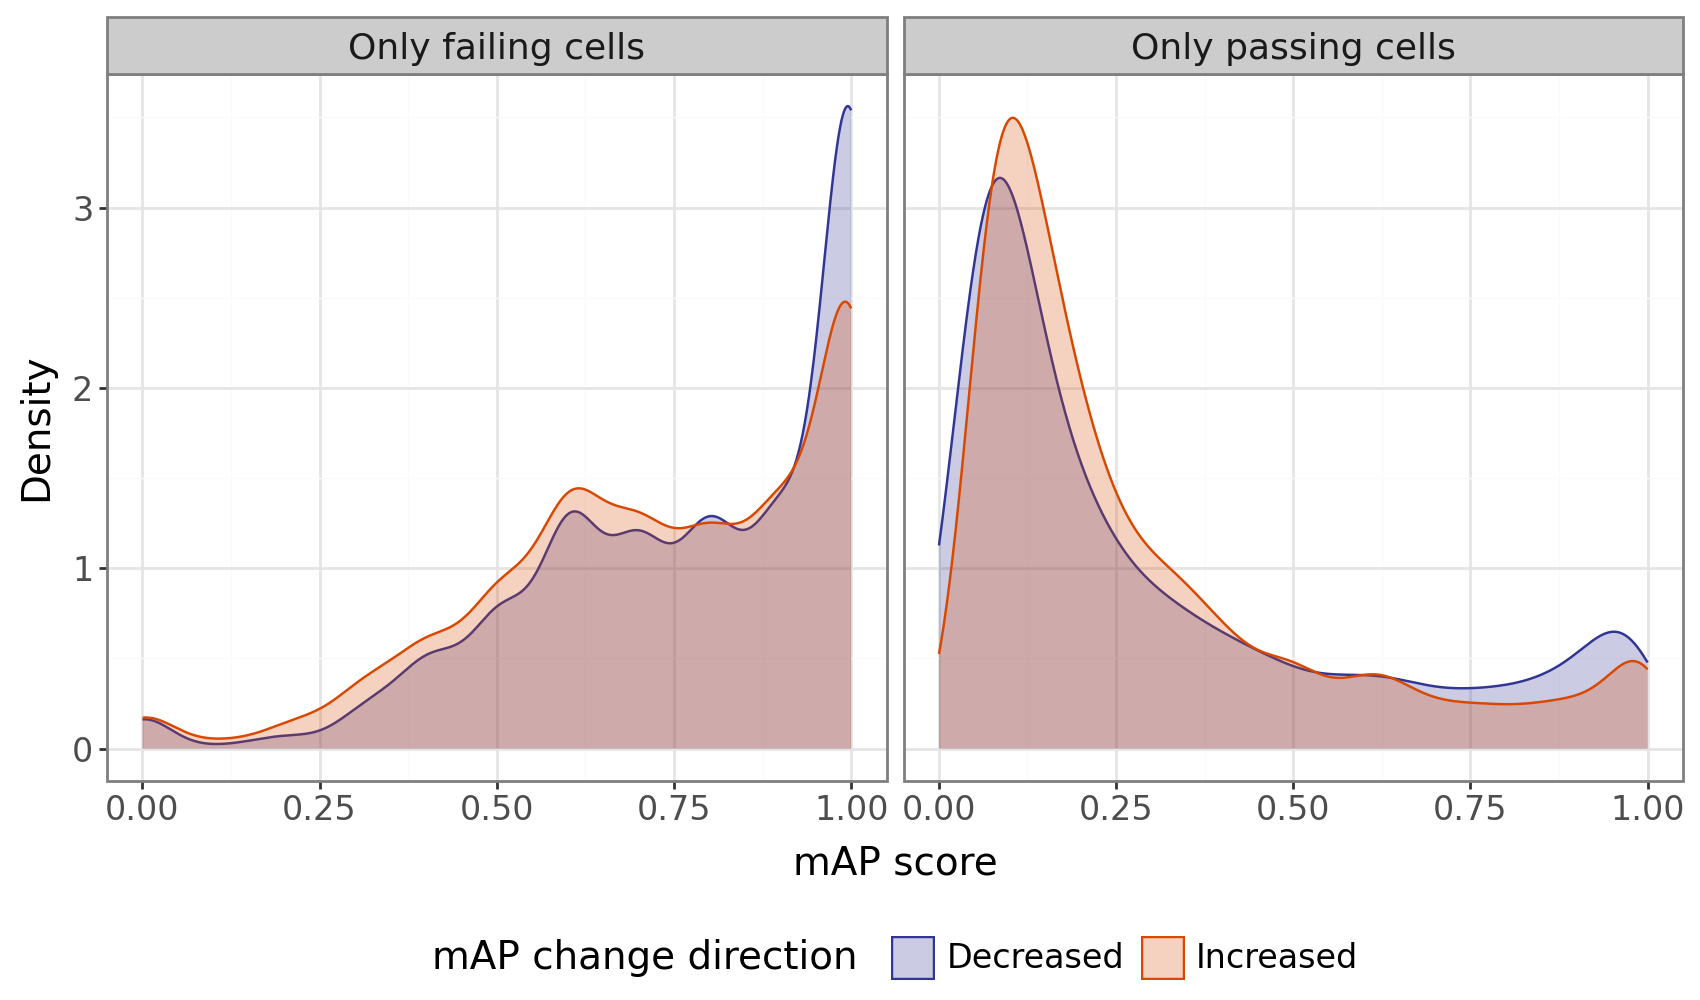

In [ ]:
# -----------------------------
# 1. Merge trend_map into BOTH QC datasets (failing_QC already has it, but redo for consistency)
# -----------------------------
final_map_postQC_trend_labeled = final_map_postQC.merge(
    trend_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
)
post_qc_labeled = passing_post_QC_map.merge(
    trend_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
)

# -----------------------------
# 2. Drop rows with no change or missing trend
# -----------------------------
final_map_postQC_trend_labeled = final_map_postQC_trend_labeled[
    final_map_postQC_trend_labeled["mAP_trend"].isin(["increase", "decrease"])
]
post_qc_labeled = post_qc_labeled[
    post_qc_labeled["mAP_trend"].isin(["increase", "decrease"])
]

# -----------------------------
# 3. Add QC labels
# -----------------------------
final_map_postQC_trend_labeled["QC_state"] = "failed_QC_cells"
post_qc_labeled["QC_state"] = "passed_QC_cells"

# -----------------------------
# 4. Combine
# -----------------------------
plot_df = pd.concat(
    [final_map_postQC_trend_labeled, post_qc_labeled], ignore_index=True
)

# -----------------------------
# 5. Standardize labels for plotting
# -----------------------------
plot_df["QC_state"] = plot_df["QC_state"].replace(
    {
        "failed_QC_cells": "Only failing cells",
        "passed_QC_cells": "Only passing cells",
    }
)
plot_df["mAP_trend"] = plot_df["mAP_trend"].replace(
    {"increase": "Increased", "decrease": "Decreased"}
)

# Diagnostic — confirm both trends are present in each QC state
print(plot_df.groupby("QC_state")["mAP_trend"].value_counts(dropna=False))

# -----------------------------
# 6. Density plot (KDE curves), faceted by QC state, colored by trend
# -----------------------------
p = (
    ggplot(
        plot_df,
        aes(
            x="mean_average_precision",
            color="mAP_trend",
            fill="mAP_trend",
        ),
    )
    + geom_density(alpha=0.25)
    + facet_wrap("~QC_state")
    + scale_color_manual(values={"Decreased": "#313695", "Increased": "#d94801"})
    + scale_fill_manual(values={"Decreased": "#313695", "Increased": "#d94801"})
    + theme_bw()
    + theme(
        figure_size=(8.5, 5),
        axis_title=element_text(size=14),
        axis_text=element_text(size=12),
        legend_title=element_text(size=14),
        legend_text=element_text(size=12),
        strip_text=element_text(size=13),
        legend_position="bottom",
    )
    + labs(
        x="mAP score",
        y="Density",
        color="mAP change direction",
        fill="mAP change direction",
    )
)
p.save("./figures/only_failing_vs_passing_mAP_scores_dist_by_trend.png", dpi=600)
p.show()

In [ ]:
failed = plot_df.loc[
    plot_df["QC_state"] == "Only failing cells",
    "mean_average_precision",
]

passed = plot_df.loc[
    plot_df["QC_state"] == "Only passing cells",
    "mean_average_precision",
]

print(len(failed), len(passed))
print(failed.median(), passed.median())
print(failed.mean(), passed.mean())

8273 8273
0.8003636413626374 0.18527203924120772
0.7544583144305637 0.3046411803695272


In [ ]:
failed = plot_df.loc[
    plot_df["QC_state"] == "Only failing cells",
    "mean_average_precision",
]

passed = plot_df.loc[
    plot_df["QC_state"] == "Only passing cells",
    "mean_average_precision",
]

stat, p = mannwhitneyu(
    failed,
    passed,
    alternative="greater",  # tests if failing > passing
)

print(f"Mann-Whitney U = {stat:.0f}")
print(f"p-value = {p:.3e}")

Mann-Whitney U = 59694683
p-value = 0.000e+00


In [ ]:
def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    gt = np.sum(x[:, None] > y)
    lt = np.sum(x[:, None] < y)

    return (gt - lt) / (len(x) * len(y))

delta = cliffs_delta(failed, passed)
print(f"Cliff's delta = {delta:.3f}")

Cliff's delta = 0.744
